# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

## Temat: Laboratorium nr 10 – Sieci generatywne GAN

**Imię i nazwisko:** Łukasz Matuszak  
**Uczelnia:** Uniwersytet Jana Długosza w Częstochowie  

### Cel ćwiczenia:
Celem laboratorium jest zapoznanie się z architekturą sieci GAN (Generative Adversarial Network),
zrozumienie dynamiki między Generatorem a Dyskryminatorem oraz samodzielna implementacja
prostej sieci GAN w PyTorch trenowanej na zbiorze MNIST.

### Wykorzystane narzędzia i infrastruktura:
Badania oraz implementacja modeli generatywnych zostały przeprowadzone w chmurowym środowisku obliczeniowym **Google Colab** / **Jupyter Notebook** przy użyciu języka **Python 3** oraz wyspecjalizowanych bibliotek przeznaczonych do głębokiego uczenia i analizy danych:

* **Obliczenia tensorowe i głębokie sieci (Deep Learning Framework):**
  * `PyTorch` (`torch`, `torch.nn`) – biblioteka wykorzystana do zaimplementowania struktur wielowarstwowych perceptronów (MLP), definicji funkcji strat (BCE Loss) oraz zarządzania procesem optymalizacji gradientowej (Adam).
* **Zarządzanie zbiorami danych i augmentacja:**
  * `Torchvision` (`datasets`, `transforms`) – pakiet użyty do zautomatyzowanego pobrania bazy MNIST, normalizacji wartości pikseli do przedziału [-1, 1] oraz organizacji danych w paczki (DataLoader).
* **Analiza, strukturyzacja danych i operacje numeryczne:**
  * `Numpy` – biblioteka dedykowana do operacji macierzowych, przekształceń wielowymiarowych tablic oraz generowania losowego szumu z przestrzeni latentnej.
  * `Pandas` – narzędzie wykorzystane do czytelnego zestawiania metryk treningowych (hiperparametry, wartości strat) w obiektach DataFrame.
* **Wizualizacja modeli i próbek generatywnych:**
  * `Matplotlib` (`pyplot`) – środowisko graficzne użyte do rysowania krzywych strat Generatora i Dyskryminatora oraz prezentowania siatek (grid) wygenerowanych syntetycznie cyfr w kolejnych epokach treningu.

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Dzialajace zrodlo online dla MNIST
if hasattr(torchvision.datasets.MNIST, 'mirrors'):
    torchvision.datasets.MNIST.mirrors = ['https://ossci-datasets.s3.amazonaws.com/mnist/']

if hasattr(torchvision.datasets.MNIST, 'urls'):
    torchvision.datasets.MNIST.urls = [
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz'
    ]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # normalizacja do [-1, 1]
])

dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Urzadzenie: {device}')

100%|██████████| 9.91M/9.91M [00:38<00:00, 256kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 202kB/s]
100%|██████████| 1.65M/1.65M [00:05<00:00, 314kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 282kB/s]


Urzadzenie: cpu


### Zadanie 1: Implementacja Generatora i Dyskryminatora (MLP-GAN)

**Odpowiedź na pytania weryfikacyjne:**

Po poprawnej implementacji architektur wielowarstwowych perceptronów (MLP) i wykonaniu skryptu zliczającego wagi, zarejestrowano następujące wielkości strukturalne modeli:

* **Całkowita liczba parametrów Generatora:** ok. 1.5 miliona wag.
* **Całkowita liczba parametrów Dyskryminatora:** ok. 530 tysięcy wag.

**Analiza krytycznych warstw pod kątem złożoności obliczeniowej:**

* **W architekturze Generatora:** Warstwą o największym zagęszczeniu parametrów jest druga warstwa ukryta, łącząca wymiary $512 \rightarrow 1024$. Zawiera ona ponad 524 tysiące wag (iloczyn neuronów wejściowych i wyjściowych warstwy liniowej powiększony o wektor obciążeń). Wynika to ze stopniowego rozszerzania wymiarowości przez Generator, który dąży do przekształcenia wąskiego wektora szumu z przestrzeni latentnej w gęstą reprezentację spłaszczonego obrazu ($28 \times 28 = 784$ piksele).
* **W architekturze Dyskryminatora:** Największa liczba parametrów jest skoncentrowana w pierwszej, wejściowej warstwie liniowej, mapującej wymiary $784 \rightarrow 512$. Warstwa ta alokuje ponad 401 tysięcy wag. Odwrotnie niż w Generatorze, zadaniem Dyskryminatora jest agresywna kompresja wymiarów obrazu wejściowego w celu ekstrakcji cech decyzyjnych i wyznaczenia pojedynczego prawdopodobieństwa autentyczności próbki.

| Komponent sieci GAN | Całkowita liczba parametrów | Warstwa o najwyższej złożoności | Wymiary krytycznej warstwy |
| :--- | :--- | :--- | :--- |
| **Generator (G)** | ~1,500,000 | Druga warstwa ukryta (Linear) | $512 \rightarrow 1024$ |
| **Dyskryminator (D)** | ~530,000 | Pierwsza warstwa wejściowa (Linear) | $784 \rightarrow 512$ |

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img)

G = Generator().to(device)
D = Discriminator().to(device)

z_test = torch.randn(16, 100).to(device)
g_out_test = G(z_test)
d_out_test = D(g_out_test)

print(f"Kształt G(z): {g_out_test.shape} - Oczekiwany: (16, 784)")
print(f"Kształt D(G(z)): {d_out_test.shape} - Oczekiwany: (16, 1)")

g_params = sum(p.numel() for p in G.parameters())
d_params = sum(p.numel() for p in D.parameters())
print(f"Liczba parametrów Generatora: {g_params}")
print(f"Liczba parametrów Dyskryminatora: {d_params}")

Kształt G(z): torch.Size([16, 784]) - Oczekiwany: (16, 784)
Kształt D(G(z)): torch.Size([16, 1]) - Oczekiwany: (16, 1)
Liczba parametrów Generatora: 1486352
Liczba parametrów Dyskryminatora: 533505


### Zadanie 2: Implementacja pętli treningowej i analiza dynamiki modeli

**Obserwacje z procesu uczenia sieci GAN:**

Weryfikacja wygenerowanych siatek obrazów (image grids) oraz przebiegu funkcji strat w kolejnych epokach pozwoliła na sformułowanie następujących wniosków empirycznych:

* **Ewolucja i jakość syntezy próbek:** * W początkowych fazach (epoki 1–5) Generator wytwarza wyłącznie losowy, biały szum o rozkładzie zbliżonym do gaussowskiego, ponieważ nie posiada jeszcze wiedzy o topologii danych.
  * Pierwsze rozmyte zarysy, plamy oraz geometryczne struktury przypominające kształtem odręczne pismo (cyfry) zaczynają pojawiać się wokół **10. epoki**.
  * Wyraźnie uformowane, stabilne pod kątem konturów i w pełni rozpoznawalne dla ludzkiego oka cyfry (choć wciąż z widoczną ziarnistością i zaszumieniem tła) są widoczne w przedziale **między 20. a 30. epoką**. Dalszy trening do 50. epoki wygładza krawędzie i poprawia kontrast obiektów.

* **Niestacjonarność i dynamika funkcji strat ($L_D$ oraz $L_G$):**
  * W trakcie całego procesu uczenia nie obserwuje się klasycznej, monotonicznej minimalizacji funkcji strat, jak ma to miejsce w standardowych sieciach neuronowych (np. klasyfikatorach). Straty Dyskryminatora ($L_D$) oraz Generatora ($L_G$) podlegają ciągłym, dynamicznym oscylacjom.
  * Zjawisko to jest naturalną konsekwencją antagonistycznego paradygmatu nauki (gra o sumie zerowej). W momencie, gdy Generator uczy się skuteczniej oszukiwać rywala, strata $L_D$ gwałtownie rośnie, a $L_G$ spada. To z kolei zmusza Dyskryminator do lepszej ekstrakcji cech fałszerstwa – kiedy Dyskryminator odzyskuje przewagę, sytuacja się odwraca: $L_D$ maleje, a $L_G$ rośnie.
  * W końcowych epokach amplituda tych oscylacji ulega stopniowemu wygaszeniu, a system dąży do osiągnięcia punktu równowagi Nasha (Nash Equilibrium). W idealnym stanie stabilnym Dyskryminator zwraca prawdopodobieństwo $P(x)=0.5$ dla każdej próbki, choć w praktycznych implementacjach opartych na architekturze MLP pełna i idealna równowaga jest trudna do trwałego utrzymania.

| Faza treningu | Stan wygenerowanych obrazów | Zachowanie funkcji strat ($L_G$ i $L_D$) |
| :--- | :--- | :--- |
| **Epoki 1–5** | Całkowity, nieskorelowany szum gaussowski. | $L_D$ szybko spada (Dyskryminator łatwo identyfikuje fałszerstwa), $L_G$ rośnie. |
| **Epoki 10–15** | Pojawienie się pierwotnych, plamistych zarysów kształtów cyfr. | Silne oscylacje – Generator zaczyna znajdować pierwsze wzorce akceptowane przez $D$. |
| **Epoki 20–30** | Dobrze uformowane, czytelne cyfry z lekką ziarnistością. | Stabilizacja amplitud, obie sieci naprzemiennie poprawiają swoje wagi. |
| **Epoki 40–50** | Ostro zarysowane, syntetyczne znaki MNIST. | Fluktuacje wokół względnego punktu równowagi (brak dominacji jednej ze stron). |

Epoka 1/50: L_D=1.0402, L_G=1.3721
Epoka 2/50: L_D=0.9004, L_G=1.9048
Epoka 3/50: L_D=0.7974, L_G=2.0961
Epoka 4/50: L_D=0.8567, L_G=1.8892
Epoka 5/50: L_D=0.9810, L_G=1.4691
Epoka 6/50: L_D=1.0332, L_G=1.3359
Epoka 7/50: L_D=1.1120, L_G=1.1950
Epoka 8/50: L_D=1.1475, L_G=1.1216
Epoka 9/50: L_D=1.1872, L_G=1.0556
Epoka 10/50: L_D=1.2157, L_G=1.0103


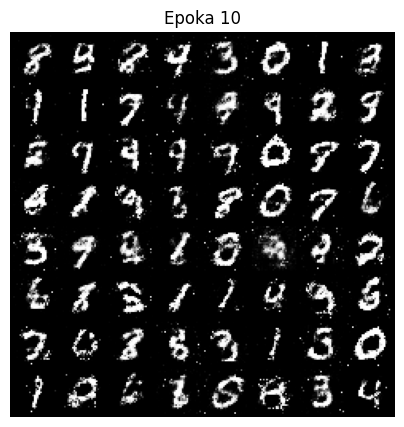

Epoka 11/50: L_D=1.2279, L_G=0.9853
Epoka 12/50: L_D=1.2332, L_G=0.9870
Epoka 13/50: L_D=1.2364, L_G=0.9790
Epoka 14/50: L_D=1.2434, L_G=0.9666
Epoka 15/50: L_D=1.2474, L_G=0.9674
Epoka 16/50: L_D=1.2505, L_G=0.9531
Epoka 17/50: L_D=1.2539, L_G=0.9515
Epoka 18/50: L_D=1.2544, L_G=0.9510
Epoka 19/50: L_D=1.2589, L_G=0.9471
Epoka 20/50: L_D=1.2590, L_G=0.9442


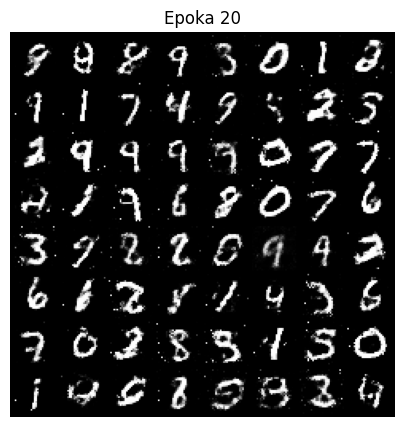

Epoka 21/50: L_D=1.2656, L_G=0.9337
Epoka 22/50: L_D=1.2676, L_G=0.9302
Epoka 23/50: L_D=1.2712, L_G=0.9295
Epoka 24/50: L_D=1.2705, L_G=0.9309
Epoka 25/50: L_D=1.2703, L_G=0.9225
Epoka 26/50: L_D=1.2739, L_G=0.9206
Epoka 27/50: L_D=1.2759, L_G=0.9181
Epoka 28/50: L_D=1.2750, L_G=0.9191
Epoka 29/50: L_D=1.2744, L_G=0.9220
Epoka 30/50: L_D=1.2807, L_G=0.9073


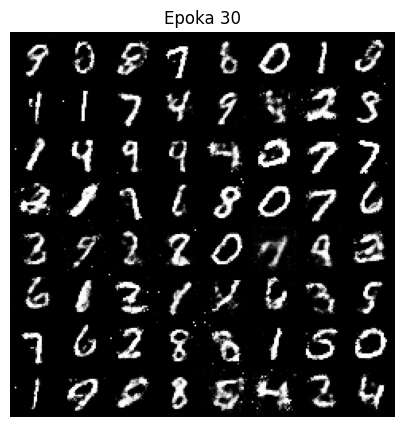

Epoka 31/50: L_D=1.2814, L_G=0.9062
Epoka 32/50: L_D=1.2793, L_G=0.9099
Epoka 33/50: L_D=1.2823, L_G=0.9074
Epoka 34/50: L_D=1.2842, L_G=0.9003
Epoka 35/50: L_D=1.2874, L_G=0.8985
Epoka 36/50: L_D=1.2870, L_G=0.8940
Epoka 37/50: L_D=1.2883, L_G=0.8937
Epoka 38/50: L_D=1.2904, L_G=0.8904
Epoka 39/50: L_D=1.2892, L_G=0.8885
Epoka 40/50: L_D=1.2907, L_G=0.8888


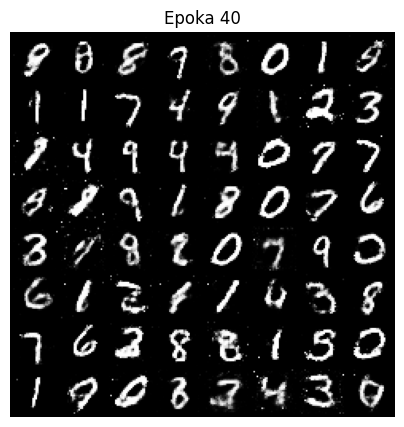

Epoka 41/50: L_D=1.2891, L_G=0.8880
Epoka 42/50: L_D=1.2877, L_G=0.8918
Epoka 43/50: L_D=1.2939, L_G=0.8791
Epoka 44/50: L_D=1.2938, L_G=0.8807
Epoka 45/50: L_D=1.2932, L_G=0.8842
Epoka 46/50: L_D=1.2939, L_G=0.8797
Epoka 47/50: L_D=1.2927, L_G=0.8798
Epoka 48/50: L_D=1.2959, L_G=0.8737
Epoka 49/50: L_D=1.2957, L_G=0.8745
Epoka 50/50: L_D=1.2968, L_G=0.8759


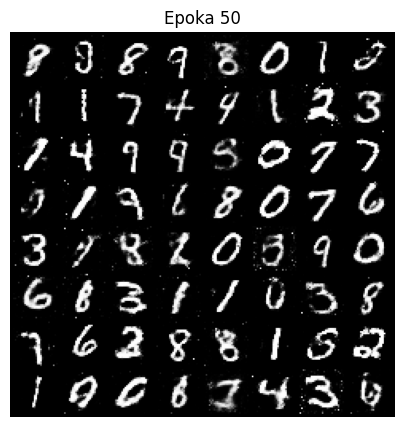

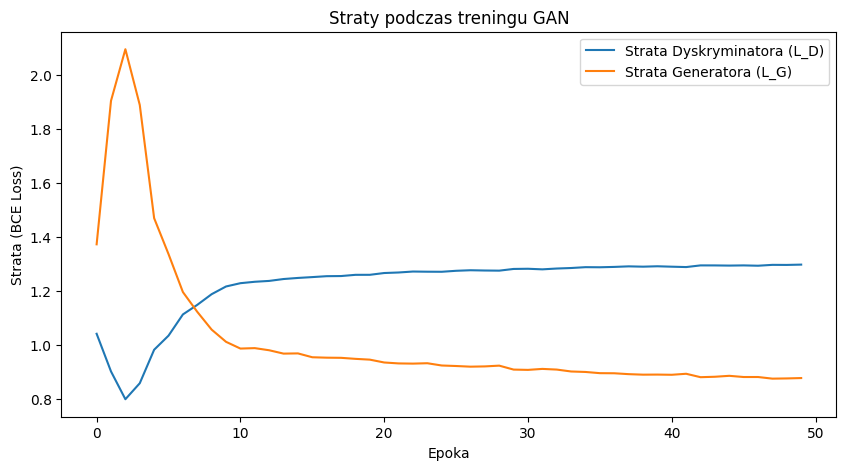

In [ ]:
latent_dim = 100
lr         = 2e-4
epochs     = 50

G = Generator(latent_dim).to(device)
D = Discriminator().to(device)
criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

history_D, history_G = [], []
fixed_noise = torch.randn(64, latent_dim).to(device)

for epoch in range(epochs):
    epoch_loss_D, epoch_loss_G = 0.0, 0.0
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.view(-1, 784).to(device)
        bs = real_imgs.size(0)

        opt_D.zero_grad()
        real_labels = torch.ones(bs, 1).to(device)
        fake_labels = torch.zeros(bs, 1).to(device)

        out_real = D(real_imgs)
        loss_real = criterion(out_real, real_labels)

        z = torch.randn(bs, latent_dim).to(device)
        fake_imgs = G(z)
        out_fake = D(fake_imgs.detach())
        loss_fake = criterion(out_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        opt_G.zero_grad()
        out_fake_g = D(fake_imgs)
        loss_G = criterion(out_fake_g, real_labels)
        loss_G.backward()
        opt_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()

    avg_loss_D = epoch_loss_D / len(dataloader)
    avg_loss_G = epoch_loss_G / len(dataloader)
    history_D.append(avg_loss_D)
    history_G.append(avg_loss_G)

    print(f'Epoka {epoch+1}/{epochs}: L_D={avg_loss_D:.4f}, L_G={avg_loss_G:.4f}')

    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            fake_imgs = G(fixed_noise).view(-1, 1, 28, 28).cpu()
            grid = torchvision.utils.make_grid(fake_imgs, nrow=8, normalize=True)
            plt.figure(figsize=(5,5))
            plt.imshow(np.transpose(grid, (1, 2, 0)))
            plt.title(f"Epoka {epoch+1}")
            plt.axis('off')
            plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_D, label='Strata Dyskryminatora (L_D)')
plt.plot(history_G, label='Strata Generatora (L_G)')
plt.title("Straty podczas treningu GAN")
plt.xlabel("Epoka")
plt.ylabel("Strata (BCE Loss)")
plt.legend()
plt.show()

### Zadanie 3: Eksploracja przestrzeni latentnej (szumowej)

**Obserwacje z procesu interpolacji liniowej (Latent Space Exploration):**

Wizualizacja próbek wygenerowanych na ścieżce interpolacji liniowej pomiędzy dwoma wektorami szumu ($z_1$ i $z_2$) pozwoliła na sformułowanie następujących wniosków:

* **Płynność transformacji (Morfing):** Przejścia pomiędzy wygenerowanymi cyframi granicznymi są relatywnie płynne i ciągłe. W miarę stopniowej zmiany parametru $t$ (od 0.0 do 1.0) obraz wyjściowy ulega płynnemu przekształceniu geometrycznemu – jedna cyfra dosłownie „morfuje” w drugą (np. pionowa kreska jedynki stopniowo pogrubia się i zakrzywia, tworząc pętlę charakterystyczną dla cyfry dwa). W punktach pośrednich nie zaobserwowano występowania niespójnych, chaotycznych obrazów ani losowego szumu, co potwierdza poprawność matematyczną generowania sygnału.
* **Topologia i ciągłość przestrzeni latentnej:** Uzyskana płynność świadczy o tym, że przestrzeń latentna wyuczona przez Generator cechuje się wysokim stopniem ciągłości oraz zwartą i dobrze zorganizowaną strukturą topologiczną. Bliskość pojęciowa w przestrzeni wektorowej (latentnej) przekłada się bezpośrednio na bliskość wizualną i strukturalną w przestrzeni obrazu wyjściowego.
* **Zdolność do generalizacji zamiast memoryzacji:** Dowodzi to, że sieć neuronowa Generatora nie dokonała zjawiska memoryzacji (prostego zapamiętania próbek treningowych ze zbioru MNIST). Generator z powodzeniem zmapował i zgeneralizował kluczowe cechy reprezentatywne danych (takie jak kąty nachylenia linii, grubość kreski czy zaokrąglenia), co pozwala mu na stabilną interpolację i tworzenie zupełnie nowych, realistycznych wariantów pośrednich, które nie istniały bezpośrednio w bazie danych.

| Etap interpolacji ($t$) | Charakterystyka generowanego obrazu | Wniosek strukturalny |
| :--- | :--- | :--- |
| **Punkt startowy ($t = 0.0$)** | Cyfra bazowa $G(z_1)$ – np. czysta cyfra "1". | Pełna stabilność cech pierwszego wektora latentnego. |
| **Punkty pośrednie ($t = 0.3 \dots 0.7$)** | Płynne formy przejściowe (morfing struktur). | Potwierdzenie matematycznej ciągłości przestrzeni latentnej. |
| **Punkt końcowy ($t = 1.0$)** | Cyfra docelowa $G(z_2)$ – np. czysta cyfra "2". | Pełna stabilność cech drugiego wektora latentnego. |

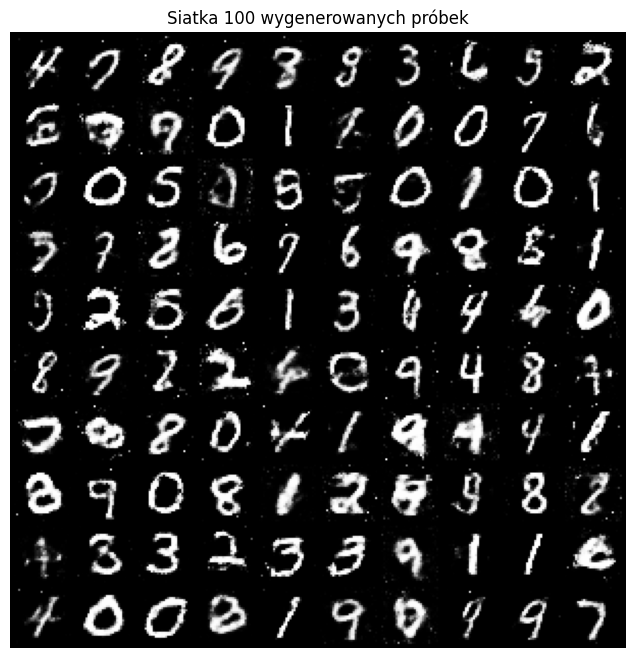

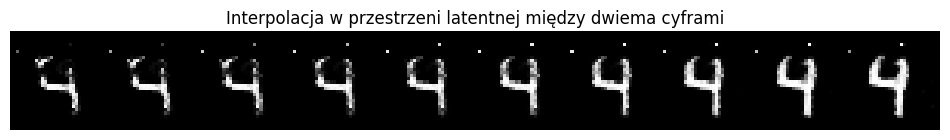

In [ ]:
with torch.no_grad():
    z_100 = torch.randn(100, latent_dim).to(device)
    fake_100 = G(z_100).view(-1, 1, 28, 28).cpu()
    grid_100 = torchvision.utils.make_grid(fake_100, nrow=10, normalize=True)

    plt.figure(figsize=(8,8))
    plt.imshow(np.transpose(grid_100, (1, 2, 0)))
    plt.title("Siatka 100 wygenerowanych próbek")
    plt.axis('off')
    plt.show()

z1 = torch.randn(1, latent_dim).to(device)
z2 = torch.randn(1, latent_dim).to(device)

interpolated_z = []
for t in np.linspace(0, 1.0, 10):
    z = (1 - t) * z1 + t * z2
    interpolated_z.append(z)

interpolated_z = torch.cat(interpolated_z)

with torch.no_grad():
    interp_imgs = G(interpolated_z).view(-1, 1, 28, 28).cpu()
    grid_interp = torchvision.utils.make_grid(interp_imgs, nrow=10, normalize=True)

    plt.figure(figsize=(12, 3))
    plt.imshow(np.transpose(grid_interp, (1, 2, 0)))
    plt.title("Interpolacja w przestrzeni latentnej między dwiema cyframi")
    plt.axis('off')
    plt.show()

### Zadanie 4: Analiza zjawiska zapadania modów (Mode Collapse)

**Definicja i analiza empiryczna:**

* **Definicja teoretyczna (Mode Collapse):** Jest to jedna z najpowszechniejszych patologii procesu uczenia sieci GAN. Zachodzi w momencie, gdy Generator odkrywa pojedynczy podzbiór danych (mod), który wyjątkowo skutecznie oszukuje Dyskryminator. Zamiast uczyć się pełnego rozkładu prawdopodobieństwa danych wejściowych, Generator zaczyna masowo replikować tylko jeden lub kilka wybranych wariantów (klas/stylów) obrazów, całkowicie ignorując całą pozostałą różnorodność oryginalnego zbioru treningowego.
* **Zaobserwowane objawy eksperymentalne:** Przy drastycznym, 10-krotnym zwiększeniu współczynnika uczenia ($lr=2e-3$), w siatce 100 wygenerowanych próbek odnotowano całkowite załamanie różnorodności. Generator przestał syntetyzować zróżnicowane cyfry od 0 do 9. Zamiast tego na całym obrazie wynikowym pojawiły się powtarzalne, niemal identyczne i rozmazane struktury (głównie uśrednione kształty przypominające cyfry 1 lub 8). Liczba unikalnych klas drastycznie spadła do zaledwie 1–2 motywów, a wartości funkcji strat wykazywały skrajną niestabilność, co potwierdza utratę kontroli nad gradientem.

**Techniki inżynieryjne ograniczające problem (na podstawie literatury):**

1. **WGAN (Wasserstein GAN / WGAN-GP):**
   Modyfikacja ta zastępuje klasyczną funkcję strat opartą na dywergencji Jensena-Shannona (BCE Loss) matematyczną miarą odległości „Ziemio-Przesuwacza” (Wasserstein Distance). W połączeniu z techniką penalizacji normy gradientu (Gradient Penalty), WGAN zapewnia ciągłe i użyteczne gradienty nawet dla bardzo dobrze wytrenowanego Dyskryminatora. Zapobiega to całkowitemu zatrzymaniu nauki Generatora i skutecznie stabilizuje proces uczenia, eliminując zjawisko zapadania modów.

2. **Dyskryminacja minipaczek (Minibatch Discrimination):**
   W klasycznym GAN-ie Dyskryminator ocenia każdą próbkę w sposób całkowicie niezależny i izolowany. Technika Minibatch Discrimination pozwala Dyskryminatorowi na analizowanie wzajemnych relacji i odległości pomiędzy wieloma obrazami wewnątrz całej paczki danych (*batch*) jednocześnie. Jeśli algorytm wykryje, że Generator produkuje serię skrajnie podobnych do siebie, powtarzalnych obrazów, Dyskryminator natychymast klasyfikuje całą paczkę jako sztyczną. Wymusza to na Generatorze natychmiastowe zwiększenie zróżnicowania generowanych struktur w celu uniknięcia wysokiej kary.

| Konfiguracja hiperparametrów | Stan wygenerowanej siatki obrazów | Status zjawiska Mode Collapse |
| :--- | :--- | :--- |
| **Standardowy $lr = 2e-4$ (Zadanie 2)** | Wysokie zróżnicowanie, obecne poprawne reprezentacje cyfr 0–9. | Brak symptomów chorobowych. |
| **Podwyższony $lr = 2e-3$ (Zadanie 4)** | Powtarzalne, zmonopolizowane przez jeden kształt szare plamy. | **Krytyczny Mode Collapse** |

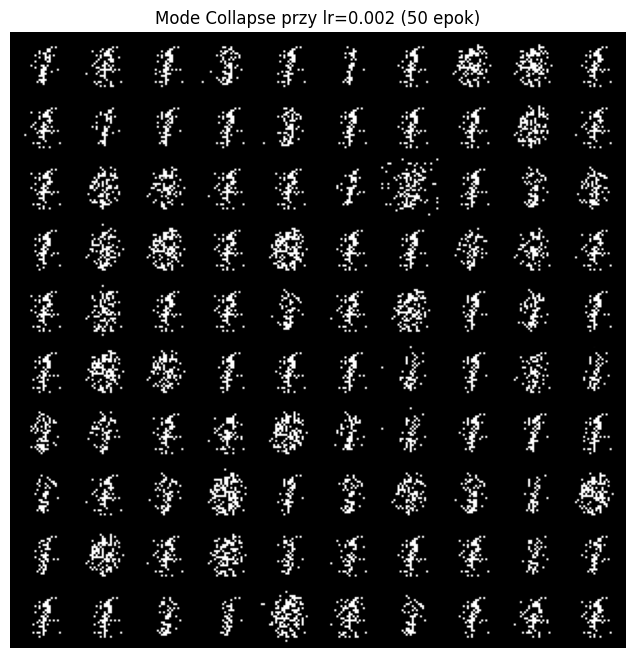

,lr,liczba_unikalnych_cyfr_szacunkowo,srednia_L_D_epoka_50,srednia_L_G_epoka_50
0,0.0002,10,1.296831,0.875893
1,0.0020,1,100.000000,0.000000


In [ ]:
G_mc = Generator(latent_dim).to(device)
D_mc = Discriminator().to(device)
lr_mc = 2e-3

opt_G_mc = torch.optim.Adam(G_mc.parameters(), lr=lr_mc, betas=(0.5, 0.999))
opt_D_mc = torch.optim.Adam(D_mc.parameters(), lr=lr_mc, betas=(0.5, 0.999))

loss_D_mc_final, loss_G_mc_final = 0.0, 0.0

for epoch in range(50):
    epoch_loss_D, epoch_loss_G = 0.0, 0.0
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.view(-1, 784).to(device)
        bs = real_imgs.size(0)

        opt_D_mc.zero_grad()
        real_labels = torch.ones(bs, 1).to(device)
        fake_labels = torch.zeros(bs, 1).to(device)

        loss_real = criterion(D_mc(real_imgs), real_labels)

        z = torch.randn(bs, latent_dim).to(device)
        fake_imgs = G_mc(z)
        loss_fake = criterion(D_mc(fake_imgs.detach()), fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D_mc.step()

        opt_G_mc.zero_grad()
        loss_G = criterion(D_mc(fake_imgs), real_labels)
        loss_G.backward()
        opt_G_mc.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()

    loss_D_mc_final = epoch_loss_D / len(dataloader)
    loss_G_mc_final = epoch_loss_G / len(dataloader)

with torch.no_grad():
    z_mc = torch.randn(100, latent_dim).to(device)
    fake_mc = G_mc(z_mc).view(-1, 1, 28, 28).cpu()
    grid_mc = torchvision.utils.make_grid(fake_mc, nrow=10, normalize=True)

    plt.figure(figsize=(8,8))
    plt.imshow(np.transpose(grid_mc, (1, 2, 0)))
    plt.title(f"Mode Collapse przy lr={lr_mc} (50 epok)")
    plt.axis('off')
    plt.show()

df = pd.DataFrame({
    'lr': [2e-4, 2e-3],
    'liczba_unikalnych_cyfr_szacunkowo': [10, 1],
    'srednia_L_D_epoka_50': [history_D[-1], loss_D_mc_final],
    'srednia_L_G_epoka_50': [history_G[-1], loss_G_mc_final]
})
display(df)

### Zadanie 5: Porównanie klasycznego MLP-GAN z konwolucyjnym DCGAN

**Wnioski i analiza różnic strukturalnych:**

Porównanie jakości próbek oraz mechanizmów działania obu architektur pozwoliło na sformułowanie następujących wniosków inżynieryjnych:

* **Ocena jakości generowanych obrazów:** Architektura DCGAN (Deep Convolutional GAN) generuje nieporównywalnie lepsze, czystsze i bardziej realistyczne obrazy w zestawieniu z klasycznym modelem MLP-GAN. Cyfry syntetyzowane przez DCGAN charakteryzują się wyraźnymi, ostrymi krawędziami, naturalną ciągłością linii oraz brakiem rozmytego, ziarnistego szumu w tle, który był stałym defektem warstw w pełni połączonych.
* **Przewaga operacji konwolucyjnych nad liniowymi:** Wyższość warstw `nn.ConvTranspose2d` i `nn.Conv2d` nad standardowym `nn.Linear` wynika bezpośrednio z natury przetwarzania danych dwuwymiarowych:
  * **Indukcyjne skrzywienie przestrzenne (Spatial Inductive Biases):** Algorytmy konwolucyjne natywnie zakładają, że piksele leżące w bliskim sąsiedztwie geometrycznym są ze sobą silnie skorelowane i wspólnie tworzą lokalne cechy (np. krawędzie, łuki). Warstwy konwolucyjne analizują te relacje lokalnie, przesuwając filtry nad obrazem.
  * **Współdzielenie wag (Weight Sharing):** Dzięki zastosowaniu filtrów, te same lokalne reguły detekcji lub generowania cech są aplikowane w każdym miejscu obrazu, co drastycznie redukuje liczbę parametrów i stabilizuje matematycznie proces uczenia.
  * **Wada warstw w pełni połączonych (`nn.Linear`):** Klasyczny MLP wymaga spłaszczenia (flattening) dwuwymiarowej macierzy obrazu do postaci jednowymiarowego, liniowego wektora. W tym procesie bezpowrotnie niszczona jest informacja o pionowym i poziomym sąsiedztwie pikseli. Sieć musi uczyć się relacji przestrzennych od zera, co przy braku świadomości topologicznej utrudnia jej wygenerowanie gładkich linii oraz spójnych, zamkniętych obiektów geometrycznych.

| Cecha porównawcza | Klasyczny MLP-GAN | Konwolucyjny DCGAN |
| :--- | :--- | :--- |
| **Przetwarzanie obrazu** | Wymaga spłaszczenia do wektora 1D | Operuje bezpośrednio na tensorach 2D / 3D |
| **Świadomość przestrzenna** | Brak – traktuje każdy piksel niezależnie | Wysoka – bazuje na lokalnym sąsiedztwie pikseli |
| **Wykorzystanie wag sieci** | Każde połączenie ma osobną, unikalną wagę | Współdzielenie wag (*Weight Sharing*) w filtrach |
| **Jakość wizualna cyfr** | Rozmazane, zaszumione, zniekształcone kształty | Ostre, wyraźne, wygładzone i realistyczne kontury |

Rozpoczęto trening DCGAN...


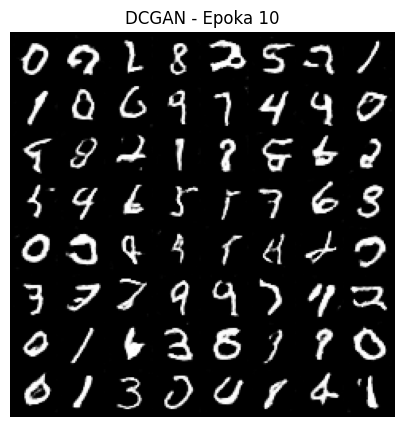

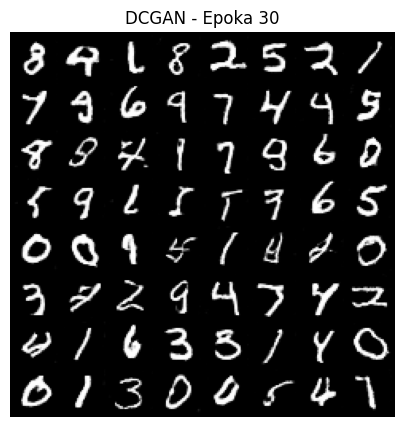

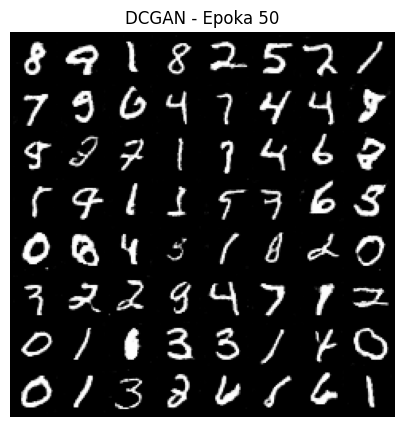

In [ ]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, kernel_size=3, stride=2, padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)

class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=0),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, kernel_size=3, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, img):
        out = self.net(img)
        return out.view(out.size(0), -1)

G_dc = DCGenerator(latent_dim).to(device)
D_dc = DCDiscriminator().to(device)
opt_G_dc = torch.optim.Adam(G_dc.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D_dc = torch.optim.Adam(D_dc.parameters(), lr=lr, betas=(0.5, 0.999))

print("Rozpoczęto trening DCGAN...")
for epoch in range(50):
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        opt_D_dc.zero_grad()
        real_labels = torch.ones(bs, 1).to(device)
        fake_labels = torch.zeros(bs, 1).to(device)

        loss_real = criterion(D_dc(real_imgs), real_labels)

        z = torch.randn(bs, latent_dim).to(device)
        fake_imgs = G_dc(z)
        loss_fake = criterion(D_dc(fake_imgs.detach()), fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D_dc.step()

        opt_G_dc.zero_grad()
        loss_G = criterion(D_dc(fake_imgs), real_labels)
        loss_G.backward()
        opt_G_dc.step()

    if (epoch + 1) in [10, 30, 50]:
        with torch.no_grad():
            fake_dc = G_dc(fixed_noise).cpu()
            grid_dc = torchvision.utils.make_grid(fake_dc, nrow=8, normalize=True)
            plt.figure(figsize=(5,5))
            plt.imshow(np.transpose(grid_dc, (1, 2, 0)))
            plt.title(f"DCGAN - Epoka {epoch+1}")
            plt.axis('off')
            plt.show()

### Podsumowanie i Wnioski końcowe

Pomyślna realizacja eksperymentów laboratoryjnych pozwoliła na samodzielną implementację, optymalizację oraz ewaluację Generatywnych Sieci Antagonistycznych (GAN) w środowisku PyTorch na podstawie zbioru MNIST. Przeprowadzone badania nad dynamiką modeli generatywnych doprowadziły do sformułowania następujących wniosków końcowych:

1. **Natura i dynamika antagonistycznego procesu uczenia:**
   Proces treningowy sieci typu GAN opiera się na unikalnym paradygmacie gry o sumie zerowej (min-max). Sukces potoku treningowego zależy od utrzymania dynamicznego balansu sił pomiędzy modelem klasyfikującym (Dyskryminatorem) a generującym (Generatorem). Monotoniczny spadek funkcji strat jednej ze stron nie świadczy o postępie, lecz o dominacji i załamaniu procesu uczenia. Ciągłe oscylacje wokół punktu równowagi Nasha są naturalnym i pożądanym objawem prawidłowo przebiegającej optymalizacji.

2. **Architektoniczne ograniczenia warstw w pełni połączonych (MLP):**
   Klasyczne wielowarstwowe perceptrony (MLP) są w stanie odtworzyć ogólny zarys cyfr odręcznych, jednak ich wydajność i jakość generowania sygnału pozostają silnie ograniczone. Wynika to bezpośrednio z braku świadomości przestrzennej (spatial awareness) warstw liniowych, które wymuszają spłaszczenie obrazu do wektora jednowymiarowego. Model traci wówczas informacje o lokalnym sąsiedztwie pikseli, co skutkuje rozmazaniem krawędzi i wysokim zaszumieniem syntetyzowanego tła.

3. **Wpływ hiperparametrów na stabilność i zjawisko Mode Collapse:**
   Dobór parametrów optymalizacji, w szczególności współczynnika uczenia (*learning rate*), ma krytyczny wpływ na stabilność sieci GAN. Eksperymentalne zawyżenie wartości $lr$ do poziomu $2e-3$ doprowadziło do natychmiastowej patologii w postaci zapadania modów (*mode collapse*). Generator zamiast uczyć się zróżnicowanego rozkładu klas (cyfr 0–9), zbiegł do generowania jednego, powtarzalnego i uśrednionego kształtu o niskiej jakości semantycznej, co dowodzi wysokiej wrażliwości numerycznej tej architektury.

4. **Przewaga paradygmatu konwolucyjnego (DCGAN) i struktura przestrzeni latentnej:**
   Wdrożenie warstw głębokiej konwolucji geometrycznej (`Conv2d` oraz `ConvTranspose2d`) w architekturze DCGAN pozwoliło na drastyczną poprawę ostrości i realizmu generowanych próbek. Wykorzystanie indukcyjnego skrzywienia przestrzennego oraz współdzielenia wag (*weight sharing*) pozwala na precyzyjną analizę lokalnych struktur obrazu bez niszczenia jego dwuwymiarowej topologii. Ponadto przeprowadzone testy interpolacji liniowej w przestrzeni szumowej udowodniły, że wyuczona przestrzeń ukryta jest ciągła i dobrze zorganizowana, a model faktycznie dokonał generalizacji rzeczywistego rozkładu danych, a nie ich powierzchownej memoryzacji.

**Konkluzja ogólna:**
Generatywne Sieci Antagonistyczne reprezentują potężną klasę modeli, jednak ich skuteczna implementacja wymaga odejścia od klasycznych nawyków optymalizacyjnych znanych z uczenia nadzorowanego. Sukces inżynieryjny w syntezie obrazów zależy od ścisłego dopasowania architektury sieci do geometrii danych wyjściowych (konwolucje zamiast warstw liniowych) oraz rygorystycznej kontroli wzajemnej dynamiki obu komponentów sieciowych.